# Feature Evaluation - Crypto Perpetuals Funding

This notebook evaluates the complete financial and model-based feature frame on
the two out-of-sample development windows used by downstream model selection.

**Learning Objectives**:
- Assemble 39 financial and five fold-specific temporal features without duplicating rows
- Compute decision-time rank IC with HAC and Benjamini-Hochberg FDR control
- Diagnose cross-sectional identifiability, feature shape, and redundancy
- Record triage diagnostics without filtering the downstream training matrix

**Book Reference**: Chapter 8, Section 8.5 (Feature Evaluation and Triage)

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb).

In [1]:
"""Evaluate crypto financial and temporal features on canonical validation folds."""

import warnings
from datetime import timedelta

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from scipy.stats import norm, spearmanr

from utils.cv_splits import load_evaluation_config
from utils.modeling import load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.style import COLORS, add_message_title

warnings.filterwarnings("ignore")

In [2]:
MAX_SYMBOLS = 0

In [3]:
CASE_STUDY_ID = "crypto_perps_funding"
PRIMARY_LABEL = "fwd_ret_8h"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

JOIN_COLS = ["timestamp", "symbol"]
HAC_MAXLAGS = 3
MIN_CROSS_SECTION = min(10, MAX_SYMBOLS) if MAX_SYMBOLS else 10
IC_THRESHOLD = 0.005
N_QUANTILES = 5

## 1. Assemble the Exact Validation Frame

`load_modeling_dataset()` is the same assembly path used by notebooks 06-11.
Its placeholder temporal join is schema-only; this notebook replaces those
columns with the matching fold artifact before evaluating each validation slice.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)
financial = pl.read_parquet(CASE_DIR / "features" / "financial.parquet")
financial_cols = [name for name in financial.columns if name not in JOIN_COLS]
temporal_cols = mds.temporal_feature_names

assert len(financial_cols) == 39
assert len(temporal_cols) == 5
assert len(mds.feature_names) == 44
assert set(mds.feature_names) == set(financial_cols) | set(temporal_cols)
assert mds.temporal_by_fold is not None

symbols = mds.dataset["symbol"].unique().to_list()
base_frame = mds.dataset.select([*JOIN_COLS, *financial_cols, mds.label_col])
temporal_by_fold = pl.from_pandas(mds.temporal_by_fold).filter(pl.col("symbol").is_in(symbols))

Each row is included once, in the fold where it is out of sample. This prevents
the many-to-many join that results from dropping `fold` before joining the
fold-keyed temporal parquet.

In [5]:
validation_frames = []
for split in mds.splits:
    base = base_frame.filter(
        pl.col("timestamp").is_between(split["val_start"], split["val_end"], closed="both")
    )
    fold_temporal = temporal_by_fold.filter(pl.col("fold") == split["fold"]).select(
        [*JOIN_COLS, *temporal_cols]
    )
    fold_temporal = fold_temporal.with_columns(
        pl.col("timestamp").cast(base.schema["timestamp"])
    ).unique(subset=JOIN_COLS)
    frame = base.join(fold_temporal, on=JOIN_COLS, how="left").with_columns(
        pl.lit(split["fold"]).alias("cv_fold")
    )
    validation_frames.append(frame)

eval_panel = pl.concat(validation_frames).sort(["timestamp", "symbol"])
assert eval_panel.select(JOIN_COLS).is_duplicated().sum() == 0
holdout_start = (
    pl.Series([load_evaluation_config(CASE_STUDY_ID)["holdout_start"]])
    .str.to_datetime()
    .dt.replace_time_zone("UTC")[0]
)
assert eval_panel["timestamp"].max() + timedelta(hours=8) < holdout_start
assert eval_panel.columns == [*JOIN_COLS, *financial_cols, mds.label_col, *temporal_cols, "cv_fold"]

print(f"Validation frame: {len(eval_panel):,} rows, {eval_panel['symbol'].n_unique()} symbols")
print(f"Decision timestamps: {eval_panel['timestamp'].n_unique():,}")
print("Feature contract: 39 financial + 5 fold-specific temporal = 44 [OK]")

Validation frame: 35,408 rows, 19 symbols
Decision timestamps: 2,183
Feature contract: 39 financial + 5 fold-specific temporal = 44 [OK]


## 2. Data Quality and Identifiability

Coverage measures whether a feature is available on the canonical validation
frame. Staleness is diagnostic rather than a failure rule because cost tier and
fold-fitted GARCH parameters are intentionally persistent. Cross-sectional IC
additionally requires variation across symbols at the same timestamp.

In [6]:
quality_rows = []
for feature in mds.feature_names:
    ordered = eval_panel.sort(["symbol", "timestamp"])
    unchanged = ordered.select(
        (pl.col(feature) == pl.col(feature).shift(1).over("symbol")).sum()
    ).item()
    varying_dates = (
        eval_panel.group_by("timestamp")
        .agg(pl.col(feature).drop_nulls().n_unique().alias("n_unique"))
        .filter(pl.col("n_unique") >= 2)
        .height
    )
    quality_rows.append(
        {
            "feature": feature,
            "source": "temporal" if feature in temporal_cols else "financial",
            "coverage": 1 - eval_panel[feature].null_count() / len(eval_panel),
            "staleness": unchanged / max(len(eval_panel) - eval_panel["symbol"].n_unique(), 1),
            "overall_unique": eval_panel[feature].drop_nulls().n_unique(),
            "varying_date_fraction": varying_dates / eval_panel["timestamp"].n_unique(),
        }
    )

quality = pl.DataFrame(quality_rows).with_columns(
    ((pl.col("coverage") >= 0.90) & (pl.col("overall_unique") >= 2)).alias("quality_pass"),
    (pl.col("varying_date_fraction") > 0).alias("cross_sectionally_identifiable"),
)
assert quality.filter(~pl.col("quality_pass")).is_empty()
print(
    quality.group_by("source").agg(
        pl.len().alias("features"),
        pl.col("coverage").min().alias("minimum_coverage"),
        pl.col("cross_sectionally_identifiable").sum().alias("identifiable"),
    )
)

shape: (2, 4)
┌───────────┬──────────┬──────────────────┬──────────────┐
│ source    ┆ features ┆ minimum_coverage ┆ identifiable │
│ ---       ┆ ---      ┆ ---              ┆ ---          │
│ str       ┆ u32      ┆ f64              ┆ u32          │
╞═══════════╪══════════╪══════════════════╪══════════════╡
│ financial ┆ 39       ┆ 1.0              ┆ 37           │
│ temporal  ┆ 5        ┆ 0.915499         ┆ 3            │
└───────────┴──────────┴──────────────────┴──────────────┘


Four common market-state columns are not cross-sectionally identifiable at a
decision timestamp: funding session and funding dispersion from the financial
frame, plus both HMM probabilities. They remain valid conditioning variables in
the 44-column training frame and are not removed by this diagnostic.

## 3. Decision-Time IC and HAC Inference

IC is Spearman correlation within each decision timestamp. The resulting time
series is ordered before Newey-West inference. This notebook never pools rows
across dates or averages per-fold summary statistics.

In [7]:
identifiable = quality.filter(pl.col("cross_sectionally_identifiable"))["feature"].to_list()
partitions = eval_panel.partition_by("timestamp", as_dict=True, maintain_order=True)
ic_results = {}
ic_timeseries = {}

for feature in identifiable:
    observations = []
    for key, group in partitions.items():
        values = group.select(feature, mds.label_col, "cv_fold").drop_nulls()
        if len(values) < MIN_CROSS_SECTION or values[feature].n_unique() < 2:
            continue
        ic, _ = spearmanr(values[feature].to_numpy(), values[mds.label_col].to_numpy())
        if np.isfinite(ic):
            timestamp = key[0] if isinstance(key, tuple) else key
            observations.append(
                {
                    "timestamp": timestamp,
                    "cv_fold": values["cv_fold"][0],
                    "ic": ic,
                    "n_obs": len(values),
                }
            )
    if len(observations) >= 20:
        series = pl.DataFrame(observations).sort("timestamp")
        ic_results[feature] = compute_ic_hac_stats(series["ic"].to_numpy(), maxlags=HAC_MAXLAGS)
        ic_timeseries[feature] = series

print(f"IC evaluated: {len(ic_results)} of 44 features")
print(f"Not cross-sectionally identifiable: {44 - len(ic_results)}")

IC evaluated: 40 of 44 features
Not cross-sectionally identifiable: 4


Fold stability uses the same two validation windows. With two folds, a
consistency score of 1.0 means the sign agrees in both windows.

In [8]:
fold_stats = {}
for feature, series in ic_timeseries.items():
    per_fold = series.group_by("cv_fold").agg(pl.col("ic").mean()).sort("cv_fold")
    fold_ics = per_fold["ic"].to_list()
    overall_sign = np.sign(ic_results[feature]["mean_ic"])
    fold_stats[feature] = {
        "n_folds": len(fold_ics),
        "sign_consistency": float(np.mean([np.sign(value) == overall_sign for value in fold_ics])),
        "worst_fold_ic": min(fold_ics, key=abs),
        "best_fold_ic": max(fold_ics, key=abs),
    }

stable_count = sum(stats["sign_consistency"] == 1.0 for stats in fold_stats.values())
print(f"Same IC sign in both validation folds: {stable_count}/{len(fold_stats)}")

Same IC sign in both validation folds: 35/40


## 4. Multiple Testing

Benjamini-Hochberg correction covers every cross-sectionally identifiable
feature. Naive and HAC significance counts use their respective t-statistics;
neither count is inferred from the other's p-values.

In [9]:
feature_names = list(ic_results)
hac_p_values = [ic_results[name]["p_value"] for name in feature_names]
naive_p_values = [2 * norm.sf(abs(ic_results[name]["naive_t_stat"])) for name in feature_names]
fdr_result = benjamini_hochberg_fdr(hac_p_values, alpha=0.05, return_details=True)

eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": ["temporal" if name in temporal_cols else "financial" for name in feature_names],
        "mean_ic": [ic_results[name]["mean_ic"] for name in feature_names],
        "hac_t": [ic_results[name]["t_stat"] for name in feature_names],
        "hac_p": hac_p_values,
        "naive_t": [ic_results[name]["naive_t_stat"] for name in feature_names],
        "naive_p": naive_p_values,
        "fdr_p": list(fdr_result["adjusted_p_values"]),
        "fdr_sig": list(fdr_result["rejected"]),
    }
).sort(pl.col("mean_ic").abs(), descending=True)

n_naive = sum(value < 0.05 for value in naive_p_values)
n_hac = sum(value < 0.05 for value in hac_p_values)
n_fdr = int(fdr_result["n_rejected"])
print(f"Significant features: naive={n_naive}, HAC={n_hac}, FDR={n_fdr}")

Significant features: naive=30, HAC=30, FDR=28


The ranked chart shows sign and magnitude; color distinguishes features that
survive FDR control without implying that non-significant conditioning features
should be discarded.

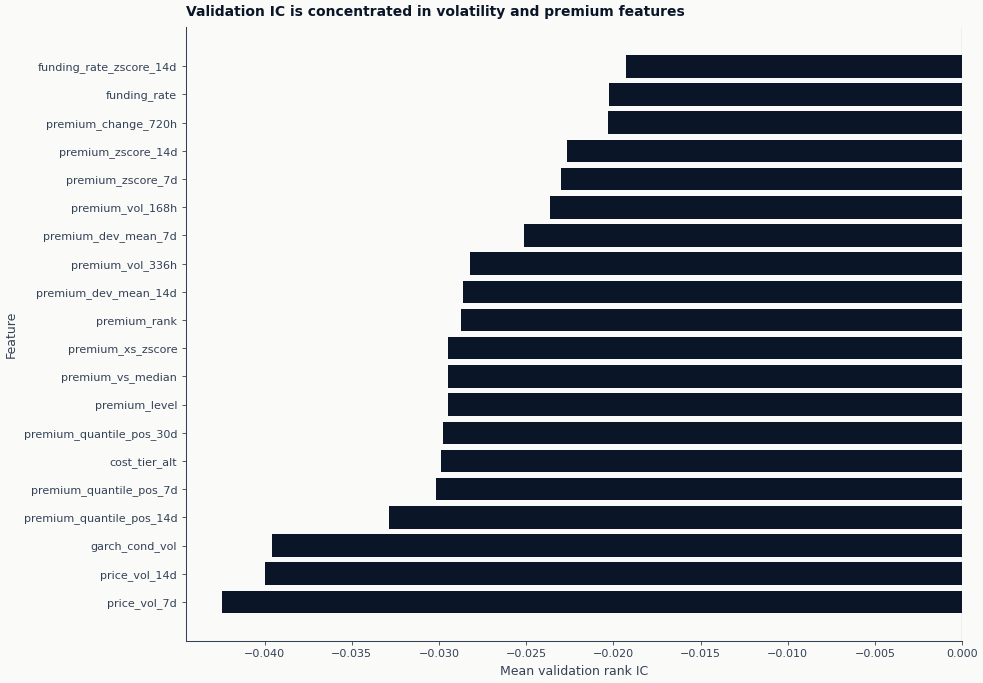

In [10]:
top_ic = eval_summary.head(20).sort("mean_ic")
fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = [COLORS["blue"] if value else COLORS["neutral"] for value in top_ic["fdr_sig"]]
ax.barh(top_ic["feature"].to_list(), top_ic["mean_ic"].to_list(), color=bar_colors)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set(xlabel="Mean validation rank IC", ylabel="Feature")
add_message_title(ax, "Validation IC is concentrated in volatility and premium features")
fig.tight_layout()
plt.show()

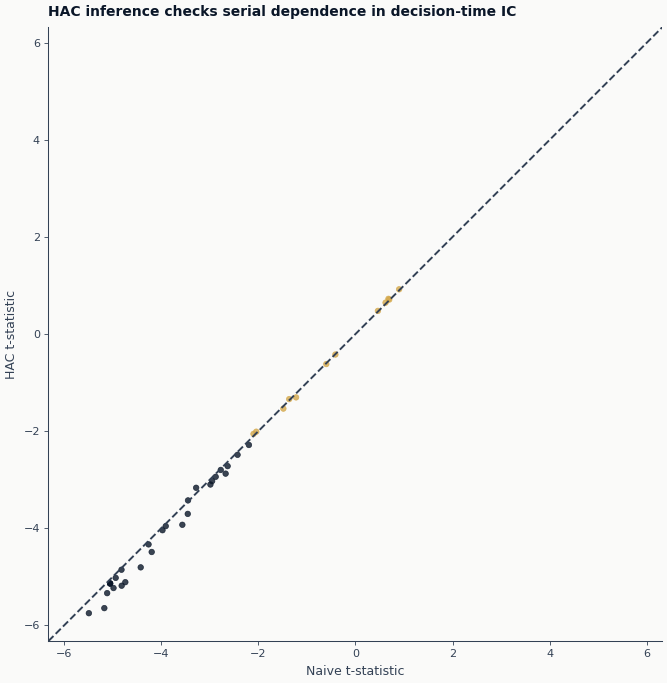

In [11]:
limit = 1.1 * max(eval_summary["naive_t"].abs().max(), eval_summary["hac_t"].abs().max())
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    eval_summary["naive_t"].to_list(),
    eval_summary["hac_t"].to_list(),
    color=[COLORS["blue"] if value else COLORS["amber"] for value in eval_summary["fdr_sig"]],
    alpha=0.8,
)
ax.plot([-limit, limit], [-limit, limit], color=COLORS["neutral"], linestyle="--")
ax.set(
    xlabel="Naive t-statistic", ylabel="HAC t-statistic", xlim=(-limit, limit), ylim=(-limit, limit)
)
ax.set_aspect("equal", adjustable="box")
add_message_title(ax, "HAC inference checks serial dependence in decision-time IC")
fig.tight_layout()
plt.show()

## 5. Cross-Sectional Shape

Quantiles are assigned separately at each timestamp before returns are averaged.
This preserves the cross-sectional meaning of IC and avoids letting market-wide
time trends manufacture a pooled quantile relationship.

In [12]:
shape_features = eval_summary.filter(pl.col("fdr_sig"))["feature"].to_list()[:6]
if not shape_features:
    shape_features = eval_summary.head(6)["feature"].to_list()

quantile_profiles = {}
monotonicity = {}
for feature in shape_features:
    valid = eval_panel.select("timestamp", feature, mds.label_col).drop_nulls()
    ranked = valid.with_columns(
        (
            (pl.col(feature).rank(method="ordinal").over("timestamp") - 1)
            * N_QUANTILES
            / pl.len().over("timestamp")
        )
        .floor()
        .clip(0, N_QUANTILES - 1)
        .cast(pl.Int8)
        .alias("quantile")
    )
    profile = ranked.group_by("quantile").agg(pl.col(mds.label_col).mean()).sort("quantile")
    means = profile[mds.label_col].to_list()
    quantile_profiles[feature] = means
    monotonicity[feature] = float(spearmanr(range(len(means)), means).statistic)

print(
    f"Strongly monotone profiles: {sum(abs(value) >= 0.8 for value in monotonicity.values())}/{len(monotonicity)}"
)

Strongly monotone profiles: 2/6


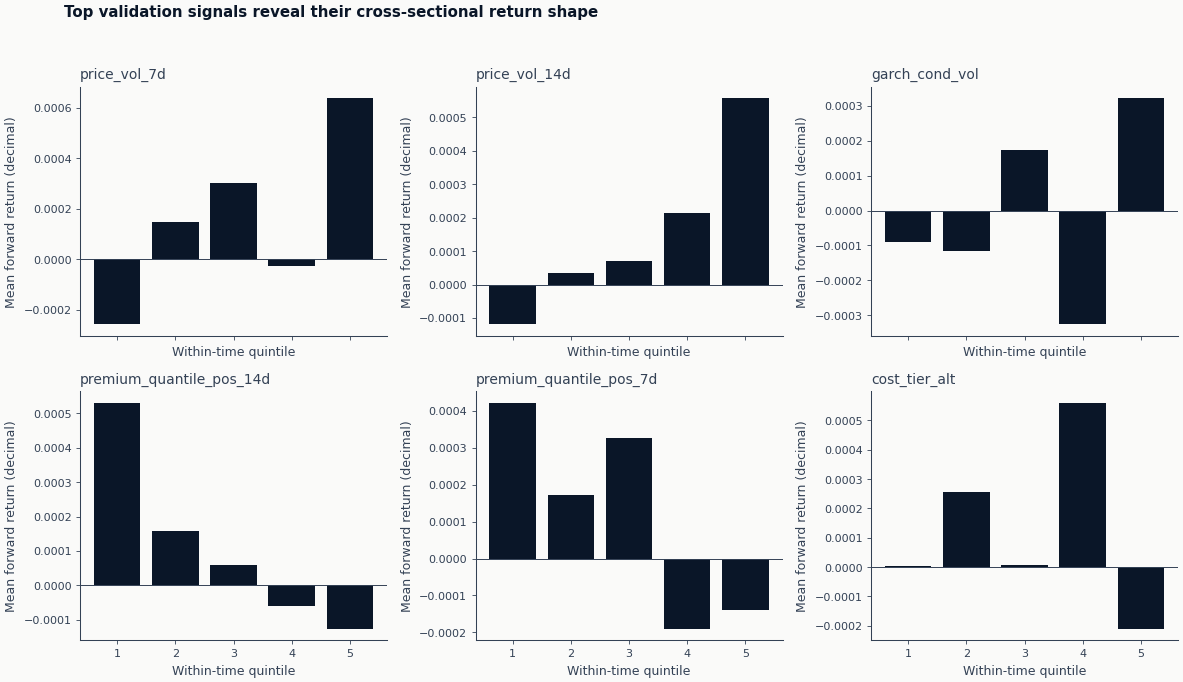

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True)
for ax, feature in zip(axes.flat, shape_features, strict=False):
    means = quantile_profiles[feature]
    ax.bar(range(1, len(means) + 1), means, color=COLORS["blue"])
    ax.axhline(0, color=COLORS["neutral"], linewidth=0.7)
    ax.set_title(feature)
    ax.set_xlabel("Within-time quintile")
    ax.set_ylabel("Mean forward return (decimal)")
for ax in axes.flat[len(shape_features) :]:
    ax.set_visible(False)
fig.suptitle(
    "Top validation signals reveal their cross-sectional return shape",
    x=0.06,
    ha="left",
    color=COLORS["blue"],
    fontweight="semibold",
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

## 6. Redundancy and Feature Families

The family map is one-to-one and matches notebook 03. Temporal features form
separate volatility and regime families.

In [14]:
financial_families = {
    "carry_funding": [
        name
        for name in financial_cols
        if name.startswith("premium_zscore_")
        or name.startswith("funding_rate")
        or name
        in {"premium_level", "premium_rank", "cum_positive_funding_7d", "funding_half_life_14d"}
    ],
    "mean_reversion": [
        name
        for name in financial_cols
        if any(key in name for key in ["dev_mean", "quantile_pos", "persistence"])
    ],
    "momentum": [
        name
        for name in financial_cols
        if name.startswith("premium_change_") or name.startswith("premium_accel_")
    ],
    "volatility": [
        name
        for name in financial_cols
        if name.startswith(("premium_vol_", "price_vol_", "vol_ratio_"))
    ],
    "cross_sectional": [
        name
        for name in financial_cols
        if name in {"premium_vs_median", "premium_xs_zscore", "xs_funding_dispersion"}
    ],
    "regime_calendar": [
        name
        for name in financial_cols
        if name.startswith(("premium_regime_", "premium_rsi_"))
        or name in {"funding_session", "cost_tier_alt"}
    ],
}

Temporal family membership follows the model that produced each column.

In [15]:
families = {
    **financial_families,
    "temporal_volatility": [name for name in temporal_cols if name.startswith("garch_")],
    "temporal_regime": [name for name in temporal_cols if name.startswith("hmm_")],
}
memberships = {
    name: [family for family, columns in families.items() if name in columns]
    for name in mds.feature_names
}
assert all(len(value) == 1 for value in memberships.values())
feature_family = {name: value[0] for name, value in memberships.items()}

In [16]:
sample_dates = (
    eval_panel["timestamp"]
    .unique()
    .sort()
    .gather_every(max(1, eval_panel["timestamp"].n_unique() // 200))
)
correlation_sample = eval_panel.filter(pl.col("timestamp").is_in(sample_dates))
high_corr_pairs = []
for left_idx, left in enumerate(identifiable):
    for right in identifiable[left_idx + 1 :]:
        pair = correlation_sample.select(left, right).drop_nulls()
        if len(pair) < 20:
            continue
        correlation = float(spearmanr(pair[left].to_numpy(), pair[right].to_numpy()).statistic)
        if np.isfinite(correlation) and abs(correlation) > 0.7:
            high_corr_pairs.append((left, right, correlation))

high_corr_pairs.sort(key=lambda item: abs(item[2]), reverse=True)
print(f"Feature pairs with |rho| > 0.7: {len(high_corr_pairs)}")

Feature pairs with |rho| > 0.7: 50


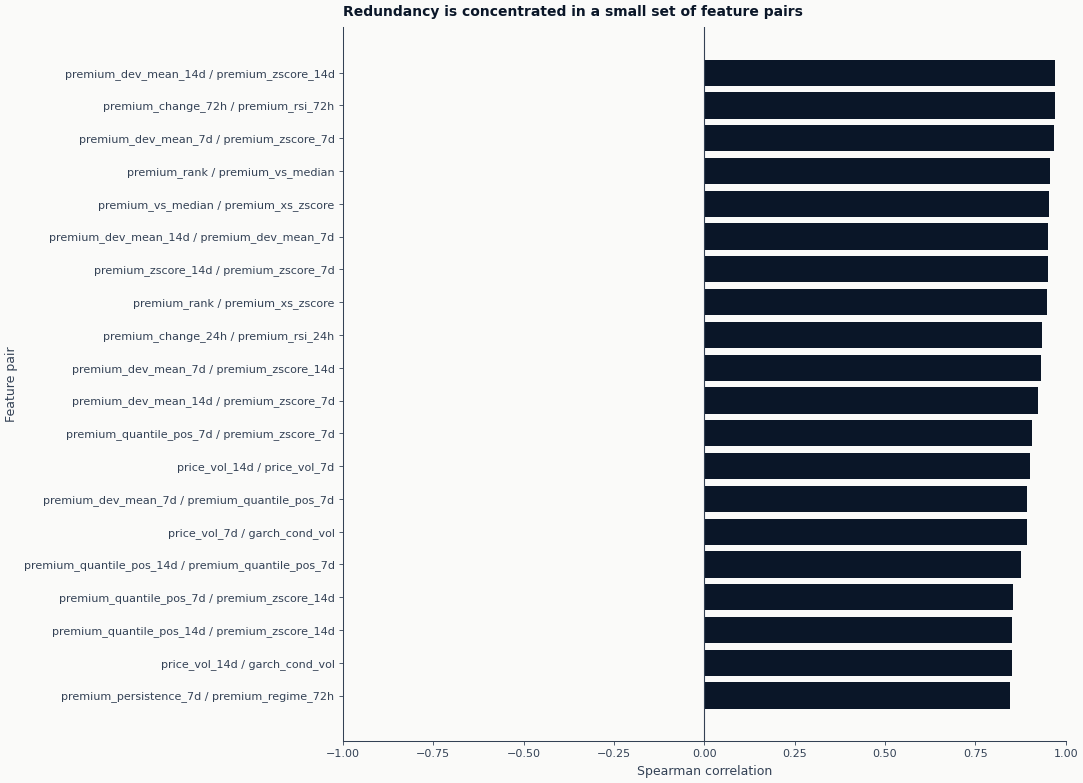

In [17]:
pair_plot = high_corr_pairs[:20][::-1]
pair_labels = [f"{left} / {right}" for left, right, _ in pair_plot]
pair_values = [value for _, _, value in pair_plot]
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(
    pair_labels,
    pair_values,
    color=[COLORS["blue"] if value >= 0 else COLORS["amber"] for value in pair_values],
)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set(xlabel="Spearman correlation", ylabel="Feature pair", xlim=(-1, 1))
add_message_title(ax, "Redundancy is concentrated in a small set of feature pairs")
fig.tight_layout()
plt.show()

## 7. Triage Ledger

`PROCEED` means the feature has useful univariate validation evidence. `REVISE`
means it remains a plausible conditioning or interaction variable. `STOP` is
reserved for an upstream quality failure. These labels are diagnostic only:
downstream notebooks continue to train the declared 44-feature matrix, avoiding
a second layer of selection on the same validation windows.

In [18]:
def assign_triage(feature: str, quality_row: dict, result: dict | None) -> tuple[str, str]:
    """Apply diagnostic triage without changing the model input contract."""
    if not quality_row["quality_pass"]:
        return "STOP", "quality_failure"
    if result is None:
        return "REVISE", "conditioning_not_cross_sectional"
    is_fdr = bool(fdr_lookup[feature]["fdr_sig"])
    stable = fold_stats[feature]["sign_consistency"] == 1.0
    above_threshold = abs(result["mean_ic"]) >= IC_THRESHOLD
    if is_fdr:
        return "PROCEED", "fdr_significant"
    if stable and above_threshold:
        return "PROCEED", "stable_above_threshold"
    return "REVISE", "weak_univariate"

The ledger retains the evidence needed to reproduce each label.

In [19]:
fdr_lookup = {row["feature"]: row for row in eval_summary.to_dicts()}
ledger_rows = []
for feature in mds.feature_names:
    quality_row = quality.filter(pl.col("feature") == feature).row(0, named=True)
    result = ic_results.get(feature)
    decision, note = assign_triage(feature, quality_row, result)
    ledger_rows.append(
        {
            "feature": feature,
            "family": feature_family[feature],
            "source": quality_row["source"],
            "mean_ic": None if result is None else result["mean_ic"],
            "hac_t": None if result is None else result["t_stat"],
            "fdr_p": None if result is None else fdr_lookup[feature]["fdr_p"],
            "sign_consistency": None if result is None else fold_stats[feature]["sign_consistency"],
            "monotonicity": monotonicity.get(feature),
            "coverage": quality_row["coverage"],
            "staleness": quality_row["staleness"],
            "decision": decision,
            "note": note,
        }
    )

triage_ledger = pl.DataFrame(ledger_rows)
triage_ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")
print(triage_ledger.group_by("decision").len().sort("decision"))

shape: (2, 2)
┌──────────┬─────┐
│ decision ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ PROCEED  ┆ 32  │
│ REVISE   ┆ 12  │
└──────────┴─────┘


In [20]:
ic_ts_all = pl.concat(
    [
        series.with_columns(pl.lit(feature).alias("feature"))
        for feature, series in ic_timeseries.items()
    ]
)
ic_ts_all.write_parquet(EVAL_DIR / "ic_timeseries.parquet")
print(f"Saved triage ledger: {len(triage_ledger)} features")
print(f"Saved IC series: {len(ic_ts_all):,} feature-timestamps")

Saved triage ledger: 44 features
Saved IC series: 79,686 feature-timestamps


## Key Takeaways

1. The evaluation frame contains each validation key once and preserves the
   current 39-plus-five feature contract; `fold` is metadata, never a feature.
2. IC is computed within each decision-time cross-section and HAC inference uses
   the ordered validation IC series from the canonical purged folds.
3. Market-level state variables remain in the training frame even though they
   cannot have cross-sectional IC at a single timestamp.
4. Triage records univariate evidence but does not filter the 44 model inputs,
   preventing validation-driven feature selection from being reused downstream.

**Next**: `06_linear` establishes regularized linear baselines on this fixed
modeling contract.